# Statistical Analysis of California Public-Sector Procurement Trends

**Capstone Project 2 - Conduct a Statistical Analysis Using Python**  
**Business context:** ICM Solutions workforce and business-development planning

## Analytical Question

Do the broad staffing-demand families represented by ICM-relevant California public-sector procurements differ by fiscal quarter?

The analysis combines five complete California fiscal years of closed bid records from California Cal eProcure, the County of El Dorado PlanetBids portal, and the City of Sacramento PlanetBids portal. Current/open bids are analyzed separately as an operational snapshot and are not included in the historical hypothesis test.

## Reproducibility and Analysis Plan

The historical analysis period is fixed in advance as **July 1, 2021 through June 30, 2026**. The workflow separates initial data screening, descriptive exploration, and hypothesis testing. This structure follows the reproducibility principle that data properties, missingness, and assumptions should be documented before inference (Lusa et al., 2024; Baillie et al., 2022).

**Pre-specified hypothesis**

- **Null hypothesis (H0):** Among ICM-relevant historical bids, staffing-demand family and fiscal quarter are independent.
- **Alternative hypothesis (H1):** The distribution of staffing-demand family differs across fiscal quarters.
- **Test:** Pearson chi-square test of independence at alpha = 0.05.
- **Effect size:** Cramer's V.

The staffing-demand families are:

1. **Technology Delivery:** software and systems integration; data, analytics, and artificial intelligence; cloud, infrastructure, and cybersecurity.
2. **Advisory, Assurance & Change:** information technology consulting and staff augmentation; project management, independent verification and validation, and quality; organizational change, training, and process improvement.

In [1]:
from pathlib import Path
import hashlib
import json
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from IPython.display import display

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 30)
pd.set_option("display.max_colwidth", 120)

PROJECT_ROOT = Path.cwd()
RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIGURE_DIR = PROJECT_ROOT / "figures"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

HISTORICAL_START = pd.Timestamp("2021-07-01 00:00:00")
HISTORICAL_END = pd.Timestamp("2026-06-30 23:59:59")
ALPHA = 0.05

SOURCE_URLS = {
    "Cal eProcure": "https://caleprocure.ca.gov/",
    "PlanetBids - El Dorado County": "https://vendors.planetbids.com/portal/48157/bo/bo-search",
    "PlanetBids - City of Sacramento": "https://vendors.planetbids.com/portal/15300/bo/bo-search",
}

print(f"Project root: {PROJECT_ROOT}")
print(f"Historical period: {HISTORICAL_START.date()} through {HISTORICAL_END.date()}")

Project root: /mnt/data/Capstone_Project_2_GitHub_Ready
Historical period: 2021-07-01 through 2026-06-30


## 1. Load the Source Files

The Cal eProcure files use an `.xls` extension but contain an HTML table export, so `pandas.read_html()` is the correct reproducible ingestion method. The PlanetBids files are UTF-8 CSV exports.

In [2]:
def parse_caleprocure(path: Path, segment: str) -> pd.DataFrame:
    """Load a Cal eProcure HTML-table export and standardize its core fields."""
    tables = pd.read_html(path)
    if len(tables) != 1:
        raise ValueError(f"Expected one table in {path.name}; found {len(tables)}")
    df = tables[0].copy()
    df = df.rename(columns={
        "Department": "agency_id_raw",
        "Department Name": "agency_name",
        "Event ID": "solicitation_id",
        "Event Name": "solicitation_title",
        "End Date": "due_datetime_raw",
        "Status": "status_raw",
        "Buyer Name": "buyer_name",
        "Buyer Email": "buyer_email",
    })
    df["source_portal"] = "Cal eProcure"
    df["source_url"] = SOURCE_URLS["Cal eProcure"]
    df["jurisdiction_level"] = "State"
    df["jurisdiction_name"] = "California"
    df["dataset_segment"] = segment
    cleaned_date = df["due_datetime_raw"].astype(str).str.replace(r"\s+(PDT|PST)$", "", regex=True)
    df["due_datetime"] = pd.to_datetime(cleaned_date, format="%m/%d/%Y %I:%M%p", errors="coerce")
    return df


def parse_planetbids(path: Path, jurisdiction_level: str, jurisdiction_name: str, portal_name: str) -> pd.DataFrame:
    """Load a PlanetBids CSV export and standardize its core fields."""
    df = pd.read_csv(path, encoding="utf-8-sig")
    df = df.rename(columns={
        "title": "solicitation_title",
        "bid-id": "solicitation_id",
        "due-date": "due_datetime_raw",
        "stage": "status_raw",
    })
    df["agency_id_raw"] = ""
    df["agency_name"] = jurisdiction_name
    df["source_portal"] = portal_name
    df["source_url"] = SOURCE_URLS[portal_name]
    df["jurisdiction_level"] = jurisdiction_level
    df["jurisdiction_name"] = jurisdiction_name
    df["dataset_segment"] = "mixed historical/current"
    df["buyer_name"] = pd.NA
    df["buyer_email"] = pd.NA
    df["due_datetime"] = pd.to_datetime(df["due_datetime_raw"], format="%m/%d/%Y %I:%M%p", errors="coerce")
    return df

state_historical_raw = parse_caleprocure(RAW_DIR / "California 5 Year Historical Bids.xls", "historical")
state_current_raw = parse_caleprocure(RAW_DIR / "California Current Bids.xls", "current")
el_dorado_raw = parse_planetbids(
    RAW_DIR / "El Dorado County - All.csv", "County", "El Dorado County", "PlanetBids - El Dorado County"
)
sacramento_raw = parse_planetbids(
    RAW_DIR / "Sacramento - All.csv", "City", "City of Sacramento", "PlanetBids - City of Sacramento"
)

raw_sources = {
    "Cal eProcure historical": state_historical_raw,
    "Cal eProcure current": state_current_raw,
    "El Dorado County all": el_dorado_raw,
    "City of Sacramento all": sacramento_raw,
}

for name, frame in raw_sources.items():
    print(f"{name}: {frame.shape[0]:,} rows x {frame.shape[1]} columns")

display(state_historical_raw.head())

Cal eProcure historical: 28,107 rows x 16 columns
Cal eProcure current: 292 rows x 16 columns
El Dorado County all: 321 rows x 16 columns
City of Sacramento all: 1,440 rows x 16 columns


,agency_id_raw,agency_name,solicitation_id,solicitation_title,Format,Type,due_datetime_raw,status_raw,buyer_name,buyer_email,source_portal,source_url,jurisdiction_level,jurisdiction_name,dataset_segment,due_datetime
0,2660,Department of Transportation,07A5126,Janitorial Services in Los Angeles County,Buy,RFx,07/01/2021 12:00PM PDT,Event Completed,Sher Shah Suri,sher.shah.suri@dot.ca.gov,Cal eProcure,https://caleprocure.ca.gov/,State,California,historical,2021-07-01 12:00:00
1,3790,Dept of Parks & Recreation,0000020025,Rock Creek SNO-PARK Restroom Maintenance,Buy,RFx,07/01/2021 2:00PM PDT,Event Completed,Traci Fortier,traci.fortier@parks.ca.gov,Cal eProcure,https://caleprocure.ca.gov/,State,California,historical,2021-07-01 14:00:00
2,77601,DGS - Statewide Procurement,0000018073,"Land Surveying Instruments, Trimble Brand",Buy,RFx,07/01/2021 2:00PM PDT,Event Completed,Amanda Lewis,amanda.lewis@dgs.ca.gov,Cal eProcure,https://caleprocure.ca.gov/,State,California,historical,2021-07-01 14:00:00
3,7760,Department of General Services,0000019685,5759 OFAM PARCS PROJECTS,Buy,RFx,07/01/2021 2:00PM PDT,Event Completed,Sara Cunningham,sara.cunningham@dgs.ca.gov,Cal eProcure,https://caleprocure.ca.gov/,State,California,historical,2021-07-01 14:00:00
4,2720,Dept of the CA Highway Patrol,0000020018,CHP MARIPOSA AREA OFFICE - PROTECTIVE CLOTHING & OPERATIONAL SUPPLIES RENTAL SERVICES,Buy,RFx,07/01/2021 2:00PM PDT,Event Completed,Kristine Dey,kristine.dey@chp.ca.gov,Cal eProcure,https://caleprocure.ca.gov/,State,California,historical,2021-07-01 14:00:00


## 2. Initial Data Analysis and Data-Quality Screening

The screening checks source coverage, date parsing, missing analytical fields, and potential duplicate identifiers before the research question is evaluated. Repeated bid IDs are not automatically removed because local portals may reuse an identifier for a reissue, amendment, or distinct posting.

In [3]:
quality_rows = []
for source_name, frame in raw_sources.items():
    quality_rows.append({
        "source_file": source_name,
        "raw_rows": len(frame),
        "missing_due_datetime": int(frame["due_datetime"].isna().sum()),
        "missing_title": int(frame["solicitation_title"].isna().sum()),
        "missing_solicitation_id": int(frame["solicitation_id"].isna().sum()),
        "minimum_due_datetime": frame["due_datetime"].min(),
        "maximum_due_datetime": frame["due_datetime"].max(),
    })
raw_quality = pd.DataFrame(quality_rows)
display(raw_quality)

historical_parts = [
    state_historical_raw[state_historical_raw["due_datetime"].between(HISTORICAL_START, HISTORICAL_END)].copy(),
    el_dorado_raw[el_dorado_raw["due_datetime"].between(HISTORICAL_START, HISTORICAL_END)].copy(),
    sacramento_raw[sacramento_raw["due_datetime"].between(HISTORICAL_START, HISTORICAL_END)].copy(),
]
historical = pd.concat(historical_parts, ignore_index=True)

print(f"Normalized historical rows: {len(historical):,}")
print(historical["jurisdiction_level"].value_counts())
assert len(historical) >= 500, "Dataset does not meet the 500-row minimum."
assert historical.shape[1] >= 6, "Dataset does not meet the six-column minimum."
assert historical["due_datetime"].notna().all(), "Historical date parsing failed."
assert historical["solicitation_title"].notna().all(), "Historical titles contain missing values."

,source_file,raw_rows,missing_due_datetime,missing_title,missing_solicitation_id,minimum_due_datetime,maximum_due_datetime
0,Cal eProcure historical,28107,0,0,0,2021-07-01 12:00:00,2026-06-30 23:00:00
1,Cal eProcure current,292,0,0,0,2026-07-27 14:00:00,2027-09-30 13:00:00
2,El Dorado County all,321,0,0,0,2021-06-09 15:00:00,2026-08-21 15:00:00
3,City of Sacramento all,1440,1,0,1,2020-09-08 16:00:00,2028-06-30 17:00:00


Normalized historical rows: 29,646
jurisdiction_level
State     28107
City       1227
County      312
Name: count, dtype: int64


In [4]:
def normalize_title(value: object) -> str:
    """Normalize a solicitation title for deterministic keyword classification."""
    text = str(value).lower().replace("&", " and ").replace("¿", "-")
    text = re.sub(r"[^a-z0-9+#/.-]+", " ", text)
    return re.sub(r"\s+", " ", text).strip()


def normalize_status(value: object) -> str:
    mapping = {
        "event completed": "Closed cycle",
        "awarded": "Awarded",
        "award pending": "Post-close / award pending",
        "closed": "Closed / outcome unavailable",
        "canceled": "Canceled",
        "cancelled": "Canceled",
        "rejected": "Rejected",
        "posted": "Open",
        "bidding": "Open",
    }
    return mapping.get(str(value).strip().lower(), "Other")


def fiscal_year_label(timestamp: pd.Timestamp) -> str:
    start_year = timestamp.year if timestamp.month >= 7 else timestamp.year - 1
    return f"FY {start_year}-{str(start_year + 1)[-2:]}"


def fiscal_quarter(timestamp: pd.Timestamp) -> str:
    month = timestamp.month
    if 7 <= month <= 9:
        return "Q1"
    if 10 <= month <= 12:
        return "Q2"
    if 1 <= month <= 3:
        return "Q3"
    return "Q4"

historical["title_normalized"] = historical["solicitation_title"].map(normalize_title)
historical["status_normalized"] = historical["status_raw"].map(normalize_status)
historical["due_date"] = historical["due_datetime"].dt.date
historical["calendar_month"] = historical["due_datetime"].dt.to_period("M").astype(str)
historical["fiscal_year"] = historical["due_datetime"].map(fiscal_year_label)
historical["fiscal_quarter"] = historical["due_datetime"].map(fiscal_quarter)

key_material = (
    historical["source_portal"].fillna("") + "|" +
    historical["agency_name"].fillna("") + "|" +
    historical["solicitation_id"].fillna("").astype(str).str.strip() + "|" +
    historical["title_normalized"] + "|" +
    historical["due_datetime"].dt.strftime("%Y-%m-%d %H:%M:%S")
)
historical["record_key"] = key_material.map(lambda x: hashlib.sha256(x.encode("utf-8")).hexdigest()[:20])

print(f"Unique composite record keys: {historical['record_key'].nunique():,}")
print(f"Duplicate composite keys: {historical['record_key'].duplicated().sum():,}")

repeated_ids = (
    historical.groupby(["source_portal", "agency_name", "solicitation_id"], dropna=False)
    .size().rename("row_count").reset_index().query("row_count > 1")
)
print(f"Repeated source/agency/bid-ID groups retained for review: {len(repeated_ids):,}")
display(repeated_ids.head(15))

Unique composite record keys: 29,646
Duplicate composite keys: 0
Repeated source/agency/bid-ID groups retained for review: 13


,source_portal,agency_name,solicitation_id,row_count
28249,PlanetBids - City of Sacramento,City of Sacramento,B22191311001,2
28269,PlanetBids - City of Sacramento,City of Sacramento,B231100141102,2
28343,PlanetBids - City of Sacramento,City of Sacramento,B23151681023,2
28421,PlanetBids - City of Sacramento,City of Sacramento,B24121461001,2
28846,PlanetBids - City of Sacramento,City of Sacramento,P22141311003,2
28868,PlanetBids - City of Sacramento,City of Sacramento,P22171811001,2
28900,PlanetBids - City of Sacramento,City of Sacramento,P23081361007,2
28929,PlanetBids - City of Sacramento,City of Sacramento,P23151131024,2
29073,PlanetBids - City of Sacramento,City of Sacramento,P25141311011,2
29225,PlanetBids - City of Sacramento,City of Sacramento,Q24051011001,2


## 3. Deterministic ICM-Relevance Classification

The source files do not include a common commodity code or scope-of-work field. Therefore, the analysis uses a transparent, title-based ruleset that favors high precision over broad recall. It identifies explicit terms aligned with ICM Solutions services and applies exclusions for physical construction, unrelated testing, guard services, and product-only renewals. Both the matched term and exclusion reason are retained for auditability.

This classification is a screening tool, not a determination that ICM is eligible, competitive, or able to perform the full solicitation scope.

In [5]:
CATEGORY_RULES = [
    ("Data, Analytics & AI", [
        r"\bdata (analytics?|science|strategy|governance|management|integration|migration|conversion|warehouse|lake|visualization|quality|catalog)\b",
        r"\bbusiness intelligence\b", r"\bpredictive analytics\b", r"\bartificial intelligence\b",
        r"\bmachine learning\b", r"\bgenerative ai\b", r"\bopen data portal\b",
        r"\bgeographic information system\b", r"\bgis (platform|system|services?|implementation|support|professional)\b",
        r"\banalytics (platform|services?|solution)\b",
    ]),
    ("Project Management, IV&V & Quality", [
        r"\bindependent verification and validation\b", r"\biv&v\b", r"\bproject management office\b", r"\bpmo\b",
        r"\b(it|information technology|technology|software|application|systems?|data|digital|cybersecurity) (project|program|portfolio) management\b",
        r"\b(project|program|portfolio) management (for|of) (it|information technology|technology|software|application|systems?|data|digital|cybersecurity)\b",
        r"\bsoftware quality assurance\b", r"\bsystem quality assurance\b", r"\bit quality assurance\b",
        r"\bsoftware testing services?\b", r"\bsystem testing services?\b",
        r"\b(it|information technology|systems?|technology) business analysis\b", r"\bcontact center business analyst\b",
        r"\brequirements (analysis|management)\b", r"\bagile (coaching|consulting|transformation)\b", r"\bscrum master\b",
    ]),
    ("Organizational Change, Training & Process", [
        r"\borganizational change management\b",
        r"\bchange management (for|services? for) (it|information technology|technology|software|application|systems?|data|digital)\b",
        r"\bbusiness process (improvement|reengineering|analysis|management)\b", r"\bprocess improvement (services?|consulting)\b",
        r"\b(technology|software|system|application|information technology|it) training\b",
        r"\btraining (for|on) (technology|software|systems?|applications?)\b", r"\btechnical training services?\b",
    ]),
    ("IT Consulting & Staff Augmentation", [
        r"\binformation technology consulting\b", r"\bit consulting\b", r"\btechnology consulting\b",
        r"\binformation technology services\b", r"\bit professional services\b", r"\btechnology professional services\b",
        r"\bit staff augmentation\b", r"\binformation technology staff augmentation\b", r"\btechnology staff augmentation\b",
        r"\benterprise architecture\b", r"\bsolution architecture\b", r"\bit strategy\b",
        r"\binformation technology strategy\b", r"\bdigital strategy\b", r"\btechnology advisory\b",
    ]),
    ("Cloud, Infrastructure & Cybersecurity", [
        r"\bcloud (services?|computing|migration|hosting|infrastructure|platform)\b", r"\bamazon web services\b", r"\bmicrosoft azure\b",
        r"\bcyber ?security\b", r"\binformation security\b", r"\bnetwork security\b", r"\bpenetration testing\b",
        r"\bvulnerability assessment\b", r"\bidentity and access management\b", r"\bit disaster recovery\b",
        r"\bbusiness continuity software\b", r"\bmanaged (it|information technology|technology) services?\b",
        r"\b(it|information technology) (support|infrastructure|network|operations) services?\b",
        r"\b(help desk|service desk)\b", r"\bdata center (services?|hosting|operations)\b",
        r"\bnetwork (management|monitoring|support) services?\b", r"\bunified communications\b", r"\bvoip\b",
        r"\bindependent security assessment\b",
    ]),
    ("Software Development & Systems Integration", [
        r"\bsoftware (development|implementation|integration|modernization|solution|services?|support services?|maintenance services?|upgrade|configuration|customization)\b",
        r"\b(application|applications) (development|implementation|integration|modernization|maintenance|support|upgrade)\b",
        r"\bsystems? integration\b", r"\bsystem integrator\b", r"\binformation systems?\b", r"\binformation management system\b",
        r"\b(case|document|records?|content|learning|permit|permitting|payment|asset|grants?|laboratory information|human resources information|risk) management system\b",
        r"\bwebsite (redesign|design|development|migration|services?|support|maintenance)\b", r"\bweb (application|development|portal)\b",
        r"\bmobile (application|app)\b", r"\benterprise resource planning\b", r"\bcustomer relationship management\b",
        r"\bsalesforce (services?|solutions?|implementation|support|consulting)\b",
        r"\bservicenow (professional services?|technical services?|implementation|support services?|managed services?)\b",
        r"\bdigital transformation\b", r"\bapplication programming interface\b", r"\bapi integration\b",
        r"\bdatabase (development|migration|modernization)\b", r"\btechnology platform\b",
        r"\bgrants? management system\b", r"\bstudent information system\b", r"\bdispatch software\b",
        r"\bscheduling software\b", r"\befax software solution\b", r"\brobotic processing tool\b",
    ]),
]

EXCLUDE_PATTERNS = [
    r"\bnon-it consulting\b", r"\bdata entry\b",
    r"\b(armed|unarmed|uniformed|on-site|onsite|campus|concert|event|athletics|crowd management|commencement) security services?\b",
    r"\bphysical security assessment\b", r"\bfire suppression testing\b", r"\bfire sprinkler\b",
    r"\b(herbicide|dust suppressant|agricultural chemical|flooring|moisture seal) application services?\b",
    r"\broadway weather information system\b", r"\bintelligent roadway information system\b", r"\bhighway advisory radios?\b",
    r"\bmodify roadway information system\b", r"\broadside weather\b", r"\bfo cable\b",
    r"\bmedbank equipment\b", r"\bonline database services\b", r"\bmulti-function devices?\b",
    r"\b(esri|salesforce|thycotic|amazon web services) .*?(licenses?|renewal|subscriptions?|enterprise agreement)\b",
    r"\bsoftware (licenses?|subscriptions?|renewal)\b(?!.*\b(implementation|support services?|consulting|integration|managed services?)\b)",
    r"\bservice virtuali[sz]ation and test data management software renewal\b", r"\bcredit monitoring services\b",
    r"\bfacility security system\b", r"\baudio video surveillance system\b",
    r"\bbusiness continuity/disaster recovery services.*mobile command center\b",
    r"\bemergency operations plans?\b", r"\bhazard mitigation plan\b",
]

COMPILED_RULES = [(category, [(re.compile(pattern), pattern) for pattern in patterns]) for category, patterns in CATEGORY_RULES]
COMPILED_EXCLUSIONS = [re.compile(pattern) for pattern in EXCLUDE_PATTERNS]


def classify_title(title: object) -> tuple[str, str]:
    normalized = normalize_title(title)
    for exclusion in COMPILED_EXCLUSIONS:
        match = exclusion.search(normalized)
        if match:
            return "Not ICM-relevant", f"Excluded: {match.group(0)}"
    for category, patterns in COMPILED_RULES:
        for pattern, _ in patterns:
            match = pattern.search(normalized)
            if match:
                return category, f"Matched: {match.group(0)}"
    return "Not ICM-relevant", "No target-service term"

classification = historical["solicitation_title"].map(classify_title)
historical["service_category"] = [item[0] for item in classification]
historical["classification_basis"] = [item[1] for item in classification]
historical["icm_relevant"] = historical["service_category"].ne("Not ICM-relevant")

technology_delivery = {
    "Software Development & Systems Integration",
    "Data, Analytics & AI",
    "Cloud, Infrastructure & Cybersecurity",
}
historical["staffing_family"] = np.select(
    [
        historical["service_category"].isin(technology_delivery),
        historical["icm_relevant"],
    ],
    ["Technology Delivery", "Advisory, Assurance & Change"],
    default="Not ICM-relevant",
)

classification_summary = pd.crosstab(historical["jurisdiction_level"], historical["service_category"], margins=True)
display(classification_summary)
print(f"ICM-relevant historical bids: {historical['icm_relevant'].sum():,} of {len(historical):,} ({historical['icm_relevant'].mean():.2%})")

service_category,"Cloud, Infrastructure & Cybersecurity","Data, Analytics & AI",IT Consulting & Staff Augmentation,Not ICM-relevant,"Organizational Change, Training & Process","Project Management, IV&V & Quality",Software Development & Systems Integration,All
jurisdiction_level,,,,,,,,
City,0,2,1,1218,0,0,6,1227
County,0,1,0,305,0,0,6,312
State,16,35,19,27947,14,9,67,28107
All,16,38,20,29470,14,9,79,29646


ICM-relevant historical bids: 176 of 29,646 (0.59%)


In [6]:
# Create a stratified audit sample for human review without claiming a measured accuracy rate.
audit_parts = []
for source in historical["jurisdiction_level"].unique():
    for relevance in [True, False]:
        subset = historical[(historical["jurisdiction_level"] == source) & (historical["icm_relevant"] == relevance)]
        audit_parts.append(subset.sample(n=min(10, len(subset)), random_state=42))
classification_audit = pd.concat(audit_parts, ignore_index=True)[[
    "record_key", "jurisdiction_level", "agency_name", "solicitation_id", "solicitation_title",
    "icm_relevant", "service_category", "classification_basis"
]]
classification_audit.to_csv(PROCESSED_DIR / "classification_audit_sample.csv", index=False)
display(classification_audit.head(20))

,record_key,jurisdiction_level,agency_name,solicitation_id,solicitation_title,icm_relevant,service_category,classification_basis
0,9141682f775d47a33ab3,State,Office of Emergency Services,0000033193,RFQ A241013928 Cybersecurity Assessment for NG 9-1-1 and 988 for CalOES,True,"Cloud, Infrastructure & Cybersecurity",Matched: cybersecurity
1,0ca12becc983a1f08777,State,Department of Transportation,20A0378,Request for Quote for Information Technology Services (RFQ-ITS) 20A0378 Strategic Information Management Solution (S...,True,IT Consulting & Staff Augmentation,Matched: information technology services
2,1cccef1607ee9e963a56,State,Department of General Services,0000037224,"RFP 37224 - CASE MANAGEMENT SYSTEM (CMS) REPLACEMENT, IMPLEMENTATION AND ONGOING SUPPORT",True,Software Development & Systems Integration,Matched: case management system
3,b5e7ea4bc9f19f144ff0,State,State Controller,EUPD90522,Information Technology Service California Multiple Award Schedule - Independent Verification and Validation Services,True,"Project Management, IV&V & Quality",Matched: independent verification and validation
4,82f6ac87e929c3c27280,State,DGS - Statewide Procurement,0000032633,Invitation to Upcoming Generative Artificial Intelligence (GenAI) large language model (LLM) Developer Showcase,True,"Data, Analytics & AI",Matched: artificial intelligence
5,577d0fe39bf6bf76501c,State,Department of Transportation,51A0554,Advanced Transportation Management System Replacement (ATMSR) System Integration,True,Software Development & Systems Integration,Matched: system integration
6,9acfc9efbe8c0033cbec,State,State Controller,ELPG90224,Request for Quote - Information Technology Services (RFQ-ITS) ELGP90224,True,IT Consulting & Staff Augmentation,Matched: information technology services
7,339664d1ebc916b0f494,State,Statewide STPD,0000025965,RFI C5611387-D CDCR Data Warehouse and Visualization Tool,True,"Data, Analytics & AI",Matched: data warehouse
8,89f540ec55271b4b66a9,State,CA STATE AUDITOR'S OFFICE,0000033277,RFP No. 25-02 Information Systems Controls Review of FI$Cal,True,Software Development & Systems Integration,Matched: information systems
9,7fb52a3c953252b0a1d3,State,Employment Development Dept,0000037768,NOTICE OF INTENT TO AWARD IFB No. 124995 - Northern/Central California Assistive Technology Training,True,"Organizational Change, Training & Process",Matched: technology training


## 4. Descriptive Statistics

The dataset includes categorical fields (source, jurisdiction, agency, status, category, quarter) and derived numeric variables (counts, rates, and monthly volumes). `describe()` is used for the numeric variables created for the analysis, while frequency tables summarize categorical fields.

In [7]:
source_summary = (
    historical.groupby(["jurisdiction_level", "source_portal"], as_index=False)
    .agg(
        total_bids=("record_key", "count"),
        icm_relevant_bids=("icm_relevant", "sum"),
        unique_agencies=("agency_name", "nunique"),
        first_due_date=("due_datetime", "min"),
        last_due_date=("due_datetime", "max"),
    )
)
source_summary["icm_relevant_rate"] = source_summary["icm_relevant_bids"] / source_summary["total_bids"]
display(source_summary)

fiscal_year_summary = (
    historical.groupby(["fiscal_year", "jurisdiction_level"], as_index=False)
    .agg(total_bids=("record_key", "count"), icm_relevant_bids=("icm_relevant", "sum"))
)
fiscal_year_summary["icm_relevant_rate"] = fiscal_year_summary["icm_relevant_bids"] / fiscal_year_summary["total_bids"]
display(fiscal_year_summary.head(15))

category_counts = (
    historical.loc[historical["icm_relevant"], "service_category"]
    .value_counts().rename_axis("service_category").reset_index(name="bid_count")
)
category_counts["share_of_icm_relevant"] = category_counts["bid_count"] / category_counts["bid_count"].sum()
display(category_counts)

monthly = (
    historical.set_index("due_datetime")
    .resample("MS")
    .agg(total_bids=("record_key", "count"), icm_relevant_bids=("icm_relevant", "sum"))
)
monthly["icm_relevant_rate"] = monthly["icm_relevant_bids"] / monthly["total_bids"]
monthly["relevant_3_month_average"] = monthly["icm_relevant_bids"].rolling(3, min_periods=1).mean()

display(monthly[["total_bids", "icm_relevant_bids", "icm_relevant_rate"]].describe())

,jurisdiction_level,source_portal,total_bids,icm_relevant_bids,unique_agencies,first_due_date,last_due_date,icm_relevant_rate
0,City,PlanetBids - City of Sacramento,1227,9,1,2021-07-02 09:40:00,2026-06-29 12:00:00,0.007335
1,County,PlanetBids - El Dorado County,312,7,1,2021-07-01 15:00:00,2026-06-29 15:00:00,0.022436
2,State,Cal eProcure,28107,160,174,2021-07-01 12:00:00,2026-06-30 23:00:00,0.005693


,fiscal_year,jurisdiction_level,total_bids,icm_relevant_bids,icm_relevant_rate
0,FY 2021-22,City,236,2,0.008475
1,FY 2021-22,County,51,1,0.019608
2,FY 2021-22,State,5487,34,0.006196
3,FY 2022-23,City,247,0,0.000000
4,FY 2022-23,County,62,2,0.032258
5,FY 2022-23,State,5700,34,0.005965
6,FY 2023-24,City,270,4,0.014815
7,FY 2023-24,County,79,2,0.025316
8,FY 2023-24,State,5571,22,0.003949
9,FY 2024-25,City,281,1,0.003559


,service_category,bid_count,share_of_icm_relevant
0,Software Development & Systems Integration,79,0.448864
1,"Data, Analytics & AI",38,0.215909
2,IT Consulting & Staff Augmentation,20,0.113636
3,"Cloud, Infrastructure & Cybersecurity",16,0.090909
4,"Organizational Change, Training & Process",14,0.079545
5,"Project Management, IV&V & Quality",9,0.051136


,total_bids,icm_relevant_bids,icm_relevant_rate
count,60.000000,60.000000,60.000000
mean,494.100000,2.933333,0.005920
std,129.363723,1.783794,0.003373
min,335.000000,0.000000,0.000000
25%,410.000000,2.000000,0.003821
50%,438.500000,3.000000,0.005825
75%,550.750000,4.000000,0.007770
max,828.000000,6.000000,0.015666


## 5. Visual Model 1 - Monthly ICM-Relevant Bid Volume

This model emphasizes timing and short-term clusters. The three-month rolling average reduces month-to-month noise while preserving changes across the five-year period.

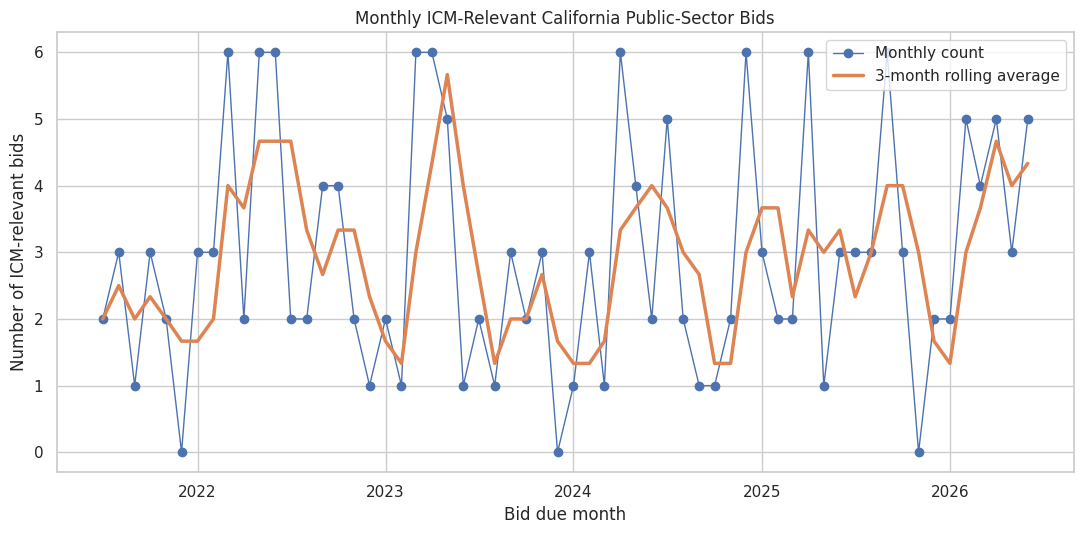

In [8]:
fig, ax = plt.subplots(figsize=(11, 5.5))
ax.plot(monthly.index, monthly["icm_relevant_bids"], marker="o", linewidth=1, label="Monthly count")
ax.plot(monthly.index, monthly["relevant_3_month_average"], linewidth=2.5, label="3-month rolling average")
ax.set_title("Monthly ICM-Relevant California Public-Sector Bids")
ax.set_xlabel("Bid due month")
ax.set_ylabel("Number of ICM-relevant bids")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURE_DIR / "figure_1_monthly_icm_relevant_bids.png", dpi=200, bbox_inches="tight")
plt.show()

## 6. Visual Model 2 - ICM-Relevant Rate by Jurisdiction

Raw state counts dominate the combined dataset. This model uses rates per 100 procurements and Wilson 95% confidence intervals, allowing the sources to be compared on a common scale while displaying the greater uncertainty in smaller local samples.

,jurisdiction_level,total_bids,icm_relevant_bids,rate,ci_low,ci_high
0,City,1227,9,0.007335,0.003864,0.013881
1,County,312,7,0.022436,0.010910,0.045579
2,State,28107,160,0.005693,0.004878,0.006642


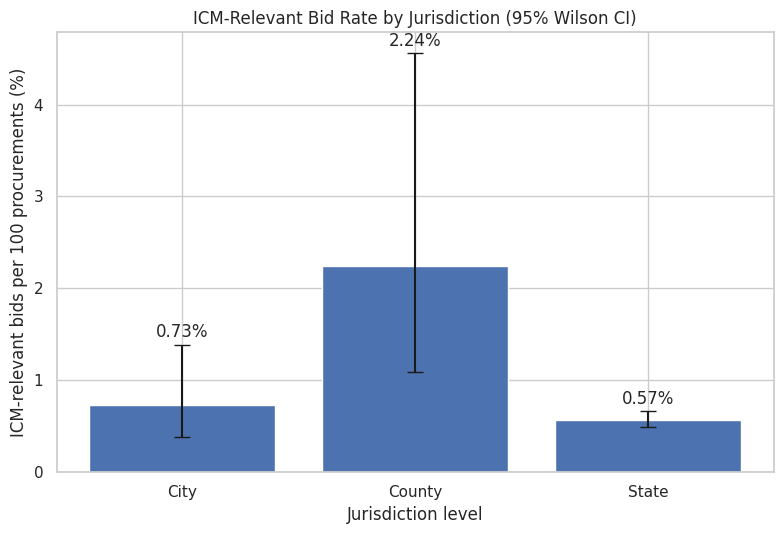

In [9]:
def wilson_interval(successes: int, total: int, confidence: float = 0.95) -> tuple[float, float]:
    if total == 0:
        return np.nan, np.nan
    z = stats.norm.ppf(1 - (1 - confidence) / 2)
    p_hat = successes / total
    denominator = 1 + z**2 / total
    center = (p_hat + z**2 / (2 * total)) / denominator
    margin = z * np.sqrt((p_hat * (1 - p_hat) / total) + z**2 / (4 * total**2)) / denominator
    return center - margin, center + margin

jurisdiction_rates = (
    historical.groupby("jurisdiction_level", as_index=False)
    .agg(total_bids=("record_key", "count"), icm_relevant_bids=("icm_relevant", "sum"))
)
jurisdiction_rates["rate"] = jurisdiction_rates["icm_relevant_bids"] / jurisdiction_rates["total_bids"]
intervals = jurisdiction_rates.apply(
    lambda row: wilson_interval(int(row["icm_relevant_bids"]), int(row["total_bids"])), axis=1
)
jurisdiction_rates[["ci_low", "ci_high"]] = pd.DataFrame(intervals.tolist(), index=jurisdiction_rates.index)
display(jurisdiction_rates)

fig, ax = plt.subplots(figsize=(8, 5.5))
y = jurisdiction_rates["rate"] * 100
lower = (jurisdiction_rates["rate"] - jurisdiction_rates["ci_low"]) * 100
upper = (jurisdiction_rates["ci_high"] - jurisdiction_rates["rate"]) * 100
ax.bar(jurisdiction_rates["jurisdiction_level"], y, yerr=np.vstack([lower, upper]), capsize=6)
ax.set_title("ICM-Relevant Bid Rate by Jurisdiction (95% Wilson CI)")
ax.set_xlabel("Jurisdiction level")
ax.set_ylabel("ICM-relevant bids per 100 procurements (%)")
for index, value in enumerate(y):
    ax.text(index, value + upper.iloc[index] + 0.08, f"{value:.2f}%", ha="center")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "figure_2_relevant_rate_by_jurisdiction.png", dpi=200, bbox_inches="tight")
plt.show()

## 7. Visual Model 3 - Staffing-Demand Family by Fiscal Quarter

This 100% stacked bar chart directly supports the hypothesis test. It compares the *composition* of ICM-relevant bids while intentionally hiding absolute volume. That trade-off makes proportional differences easier to see but requires the monthly-count model for operational volume context.

staffing_family,"Advisory, Assurance & Change",Technology Delivery
fiscal_quarter,,
Q1,9,31
Q2,9,22
Q3,12,32
Q4,13,48


staffing_family,"Advisory, Assurance & Change",Technology Delivery
fiscal_quarter,,
Q1,22.5,77.5
Q2,29.0,71.0
Q3,27.3,72.7
Q4,21.3,78.7


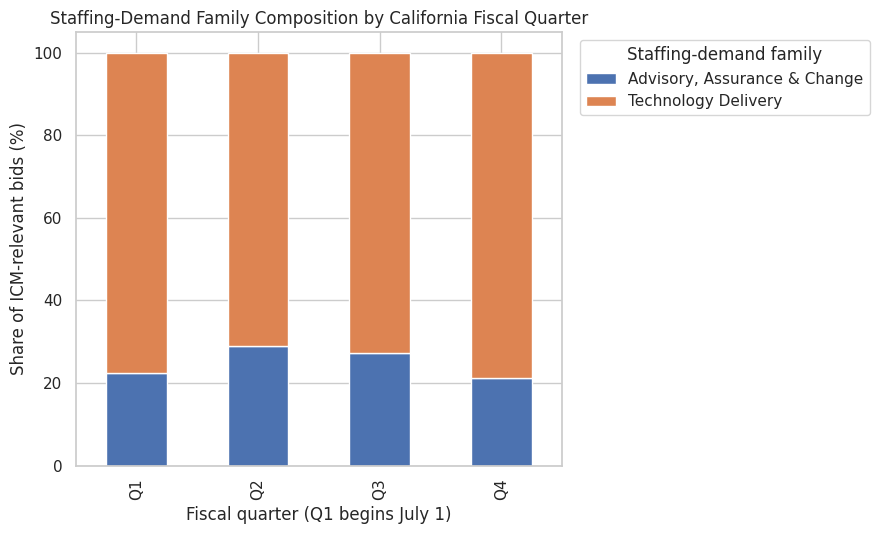

In [10]:
relevant = historical[historical["icm_relevant"]].copy()
quarter_order = ["Q1", "Q2", "Q3", "Q4"]
staffing_order = ["Advisory, Assurance & Change", "Technology Delivery"]

staffing_table = pd.crosstab(relevant["fiscal_quarter"], relevant["staffing_family"]).reindex(
    index=quarter_order, columns=staffing_order, fill_value=0
)
staffing_percent = staffing_table.div(staffing_table.sum(axis=1), axis=0) * 100
display(staffing_table)
display(staffing_percent.round(1))

ax = staffing_percent.plot(kind="bar", stacked=True, figsize=(9, 5.5))
ax.set_title("Staffing-Demand Family Composition by California Fiscal Quarter")
ax.set_xlabel("Fiscal quarter (Q1 begins July 1)")
ax.set_ylabel("Share of ICM-relevant bids (%)")
ax.legend(title="Staffing-demand family", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "figure_3_staffing_family_by_quarter.png", dpi=200, bbox_inches="tight")
plt.show()

## 8. Visual Model 4 - Detailed Service-Category Mix

This model ranks the detailed service categories. It is the clearest model for deciding *which capabilities* appear most frequently, but it does not show seasonality or uncertainty.

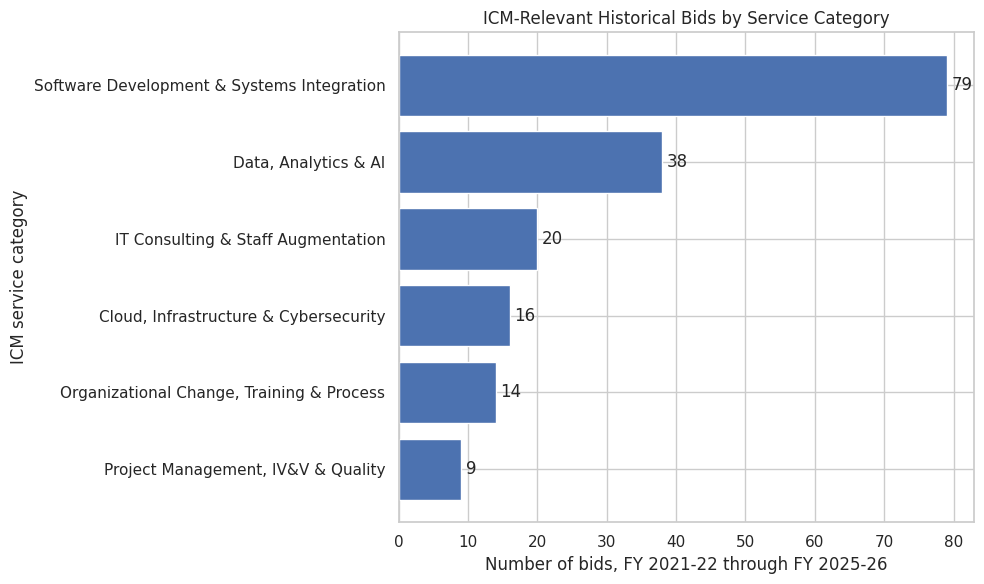

In [11]:
category_plot = category_counts.sort_values("bid_count", ascending=True)
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(category_plot["service_category"], category_plot["bid_count"])
ax.set_title("ICM-Relevant Historical Bids by Service Category")
ax.set_xlabel("Number of bids, FY 2021-22 through FY 2025-26")
ax.set_ylabel("ICM service category")
for index, value in enumerate(category_plot["bid_count"]):
    ax.text(value + 0.7, index, str(value), va="center")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "figure_4_service_category_counts.png", dpi=200, bbox_inches="tight")
plt.show()

## 9. Comparison of the Visual Models

- **Figure 1** is best for identifying bursts and operational timing, but raw monthly counts are influenced by the much larger state source and by total procurement volume.
- **Figure 2** best compares the relative concentration of ICM-relevant opportunities across jurisdiction levels. Its confidence intervals make the local-source uncertainty visible, but it does not explain which service capabilities drive the rates.
- **Figure 3** most directly supports the formal analytical question because it compares staffing-family composition across fiscal quarters. Its limitation is that a 100% chart hides absolute volume.
- **Figure 4** best supports the practical staffing decision because it identifies the dominant capability categories, but it does not represent timing.

For the hypothesis test, **Figure 3 is the most appropriate visual model**. For ICM workforce planning, Figures 1 and 4 should be used together: one addresses *when* relevant opportunities appear, and the other addresses *which capabilities* recur most frequently.

## 10. Hypothesis Test - Chi-Square Test of Independence

The chi-square test is appropriate because both variables are categorical and the analysis compares observed contingency-table counts with the counts expected under independence. The required assumption check is that expected cell frequencies are sufficiently large; every expected count is reported below.

In [12]:
chi2_statistic, p_value, degrees_of_freedom, expected = stats.chi2_contingency(staffing_table)
expected_table = pd.DataFrame(expected, index=staffing_table.index, columns=staffing_table.columns)
standardized_residuals = (staffing_table - expected_table) / np.sqrt(expected_table)
cramers_v = np.sqrt(
    chi2_statistic /
    (staffing_table.to_numpy().sum() * min(staffing_table.shape[0] - 1, staffing_table.shape[1] - 1))
)

print("Observed counts")
display(staffing_table)
print("Expected counts under H0")
display(expected_table.round(2))
print("Standardized residuals")
display(standardized_residuals.round(2))

print(f"Chi-square statistic: {chi2_statistic:.4f}")
print(f"Degrees of freedom: {degrees_of_freedom}")
print(f"p-value: {p_value:.4f}")
print(f"Minimum expected cell count: {expected.min():.2f}")
print(f"Cramer's V: {cramers_v:.4f}")

if p_value < ALPHA:
    decision = "Reject H0: the data provide evidence that staffing-demand family differs by fiscal quarter."
else:
    decision = "Fail to reject H0: the data do not provide evidence that staffing-demand family differs by fiscal quarter."
print(decision)

Observed counts


staffing_family,"Advisory, Assurance & Change",Technology Delivery
fiscal_quarter,,
Q1,9,31
Q2,9,22
Q3,12,32
Q4,13,48


Expected counts under H0


staffing_family,"Advisory, Assurance & Change",Technology Delivery
fiscal_quarter,,
Q1,9.77,30.23
Q2,7.57,23.43
Q3,10.75,33.25
Q4,14.90,46.10


Standardized residuals


staffing_family,"Advisory, Assurance & Change",Technology Delivery
fiscal_quarter,,
Q1,-0.25,0.14
Q2,0.52,-0.29
Q3,0.38,-0.22
Q4,-0.49,0.28


Chi-square statistic: 0.9502
Degrees of freedom: 3
p-value: 0.8133
Minimum expected cell count: 7.57
Cramer's V: 0.0735
Fail to reject H0: the data do not provide evidence that staffing-demand family differs by fiscal quarter.


### Statistical Interpretation

The expected-frequency assumption is satisfied because the smallest expected cell count exceeds five. The p-value is greater than 0.05, so the analysis fails to reject the null hypothesis. Cramer's V is small, indicating that the observed quarter-to-quarter differences in the two broad staffing families are weak in practical terms. The result does **not** prove that quarters are identical; it means this five-year title-based sample does not provide sufficient evidence of a systematic quarterly shift in the broad staffing mix.

## 11. Current/Open Bid Snapshot

Current bids are kept separate because they represent an incomplete future-facing period. The same classification rules are applied to identify opportunities that warrant human review. No current bid should be pursued based on title classification alone.

In [13]:
current_state = state_current_raw.copy()
current_local = pd.concat([el_dorado_raw, sacramento_raw], ignore_index=True)
current_local = current_local[
    (current_local["due_datetime"] > HISTORICAL_END) &
    (current_local["status_raw"].astype(str).str.lower() == "bidding")
].copy()
current = pd.concat([current_state, current_local], ignore_index=True)

current["title_normalized"] = current["solicitation_title"].map(normalize_title)
current["status_normalized"] = current["status_raw"].map(normalize_status)
current["due_date"] = current["due_datetime"].dt.date
current_classification = current["solicitation_title"].map(classify_title)
current["service_category"] = [item[0] for item in current_classification]
current["classification_basis"] = [item[1] for item in current_classification]
current["icm_relevant"] = current["service_category"].ne("Not ICM-relevant")
current["staffing_family"] = np.select(
    [current["service_category"].isin(technology_delivery), current["icm_relevant"]],
    ["Technology Delivery", "Advisory, Assurance & Change"],
    default="Not ICM-relevant",
)

current_key_material = (
    current["source_portal"].fillna("") + "|" + current["agency_name"].fillna("") + "|" +
    current["solicitation_id"].fillna("").astype(str).str.strip() + "|" + current["title_normalized"] + "|" +
    current["due_datetime"].dt.strftime("%Y-%m-%d %H:%M:%S")
)
current["record_key"] = current_key_material.map(lambda x: hashlib.sha256(x.encode("utf-8")).hexdigest()[:20])

print(f"Current/open records: {len(current):,}")
print(f"Current records classified as ICM-relevant: {current['icm_relevant'].sum():,}")
current_relevant = current[current["icm_relevant"]][[
    "jurisdiction_level", "agency_name", "solicitation_id", "solicitation_title",
    "due_datetime", "service_category", "source_url"
]].sort_values("due_datetime")
display(current_relevant)

Current/open records: 306
Current records classified as ICM-relevant: 5


,jurisdiction_level,agency_name,solicitation_id,solicitation_title,due_datetime,service_category,source_url
4,State,CA Health Benefit Exchange,0000039683,"RFP 2025-19 Microsoft 365 and Related Cloud Services Development, Administration, and Support",2026-07-27 16:00:00,"Cloud, Infrastructure & Cybersecurity",https://caleprocure.ca.gov/
199,State,Employment Development Dept,0000039854,RFQ No. 130123 Online/Virtual IT Training Courses,2026-08-12 17:00:00,"Organizational Change, Training & Process",https://caleprocure.ca.gov/
221,State,Franchise Tax Board,0000039691,IFB FTB-2627-76 Genesys Software Subscriptions and Application Support Services,2026-08-17 17:00:00,Software Development & Systems Integration,https://caleprocure.ca.gov/
271,State,Statewide STPD,0000039693,CALNET Managed Cybersecurity Services IFB,2026-09-14 17:00:00,"Cloud, Infrastructure & Cybersecurity",https://caleprocure.ca.gov/
291,State,"Bus & Consumer Services, Secy",0000039767,Homeless Data Integration System - Maintenance and Operations (HDIS - M&O),2027-09-30 13:00:00,"Data, Analytics & AI",https://caleprocure.ca.gov/


## 12. Save the Reproducible Analytical Outputs

In [14]:
processed_columns = [
    "record_key", "source_portal", "source_url", "jurisdiction_level", "jurisdiction_name",
    "agency_id_raw", "agency_name", "solicitation_id", "solicitation_title", "title_normalized",
    "due_datetime_raw", "due_datetime", "due_date", "calendar_month", "fiscal_year", "fiscal_quarter",
    "status_raw", "status_normalized", "buyer_name", "buyer_email", "service_category",
    "staffing_family", "icm_relevant", "classification_basis",
]

historical[processed_columns].to_csv(
    PROCESSED_DIR / "california_public_procurement_2021_2026.csv", index=False
)
historical.loc[historical["icm_relevant"], processed_columns].to_csv(
    PROCESSED_DIR / "icm_relevant_historical_bids.csv", index=False
)
current_columns = [column for column in processed_columns if column in current.columns]
current[current_columns].to_csv(
    PROCESSED_DIR / "current_public_procurement_snapshot.csv", index=False
)

DATA_DICTIONARY = [
    ("record_key", "string", "Derived", "SHA-256-based composite fingerprint of portal, agency, bid ID, normalized title, and due date."),
    ("source_portal", "category", "Standardized", "Procurement portal that supplied the record."),
    ("source_url", "string", "Added", "Public portal URL used as the data source."),
    ("jurisdiction_level", "category", "Added", "State, County, or City."),
    ("jurisdiction_name", "string", "Added", "California, El Dorado County, or City of Sacramento."),
    ("agency_id_raw", "string", "Source", "Original agency identifier when available."),
    ("agency_name", "string", "Standardized", "State department or local jurisdiction name."),
    ("solicitation_id", "string", "Source", "Original event or bid identifier."),
    ("solicitation_title", "string", "Source", "Original bid title."),
    ("title_normalized", "string", "Derived", "Lowercase title normalized for deterministic rule matching."),
    ("due_datetime_raw", "string", "Source", "Original deadline text."),
    ("due_datetime", "datetime", "Derived", "Parsed response deadline."),
    ("due_date", "date", "Derived", "Calendar date portion of the response deadline."),
    ("calendar_month", "string", "Derived", "YYYY-MM month of the deadline."),
    ("fiscal_year", "category", "Derived", "California fiscal year beginning July 1."),
    ("fiscal_quarter", "category", "Derived", "Q1 Jul-Sep, Q2 Oct-Dec, Q3 Jan-Mar, or Q4 Apr-Jun."),
    ("status_raw", "string", "Source", "Original portal status."),
    ("status_normalized", "category", "Derived", "Cross-source normalized status."),
    ("buyer_name", "string", "Source", "Buyer name where available."),
    ("buyer_email", "string", "Source", "Buyer email where available."),
    ("service_category", "category", "Derived", "Deterministic ICM service category or Not ICM-relevant."),
    ("staffing_family", "category", "Derived", "Technology Delivery; Advisory, Assurance & Change; or Not ICM-relevant."),
    ("icm_relevant", "boolean", "Derived", "Whether the title matched the high-precision ICM service rules."),
    ("classification_basis", "string", "Derived", "Matched term, exclusion reason, or no-match reason."),
]
pd.DataFrame(DATA_DICTIONARY, columns=["field", "data_type", "origin", "description"]).to_csv(
    PROCESSED_DIR / "data_dictionary.csv", index=False
)

analysis_summary = {
    "historical_period_start": str(HISTORICAL_START.date()),
    "historical_period_end": str(HISTORICAL_END.date()),
    "historical_rows": int(len(historical)),
    "state_rows": int((historical["jurisdiction_level"] == "State").sum()),
    "city_rows": int((historical["jurisdiction_level"] == "City").sum()),
    "county_rows": int((historical["jurisdiction_level"] == "County").sum()),
    "icm_relevant_rows": int(historical["icm_relevant"].sum()),
    "icm_relevant_rate": float(historical["icm_relevant"].mean()),
    "technology_delivery_rows": int((historical["staffing_family"] == "Technology Delivery").sum()),
    "advisory_assurance_change_rows": int((historical["staffing_family"] == "Advisory, Assurance & Change").sum()),
    "chi_square_statistic": float(chi2_statistic),
    "degrees_of_freedom": int(degrees_of_freedom),
    "p_value": float(p_value),
    "minimum_expected_count": float(expected.min()),
    "cramers_v": float(cramers_v),
    "current_open_rows": int(len(current)),
    "current_icm_relevant_rows": int(current["icm_relevant"].sum()),
}
with open(PROCESSED_DIR / "analysis_summary.json", "w", encoding="utf-8") as file:
    json.dump(analysis_summary, file, indent=2)

print("Saved processed datasets, data dictionary, audit sample, and analysis summary.")

Saved processed datasets, data dictionary, audit sample, and analysis summary.


## 13. Notebook Summary

This analysis standardized 29,646 historical procurements from three California public-sector sources over five complete fiscal years and identified 176 high-precision, title-based ICM-relevant records. Software development and systems integration was the largest detailed category, while the broader Technology Delivery family represented roughly three quarters of relevant records. The chi-square test found no statistically significant association between fiscal quarter and the two broad staffing-demand families, and the observed association was small. The most important analytical challenges were harmonizing different portal schemas, avoiding false matches from generic words such as *system*, *application*, *testing*, and *security*, and interpreting local-source rates with small sample sizes. For ICM Solutions, the evidence supports capability-focused staffing in software, systems integration, and data services more strongly than quarter-specific staffing surges, while current opportunities should continue to receive human scope and eligibility review.

## References Used for Methodological Decisions

Baillie, M., le Cessie, S., Schmidt, C. O., Lusa, L., & Huebner, M. (2022). Ten simple rules for initial data analysis. *PLOS Computational Biology, 18*(2), e1009819. https://doi.org/10.1371/journal.pcbi.1009819

Lusa, L., Proust-Lima, C., Schmidt, C. O., Lee, K. J., le Cessie, S., Baillie, M., Lawrence, F., & Huebner, M. (2024). Initial data analysis for longitudinal studies to build a solid foundation for reproducible analysis. *PLOS ONE, 19*(5), e0295726. https://doi.org/10.1371/journal.pone.0295726

McHugh, M. L. (2013). The chi-square test of independence. *Biochemia Medica, 23*(2), 143-149. https://doi.org/10.11613/BM.2013.018